In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style='whitegrid')


In [16]:
df = pd.read_csv('../data/raw/german_credit_data.csv')

In [17]:
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [18]:
print("\n--- Информация о датасете ---")
df.info()


--- Информация о датасете ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   checking_status         1000 non-null   str  
 1   duration                1000 non-null   int64
 2   credit_history          1000 non-null   str  
 3   purpose                 1000 non-null   str  
 4   credit_amount           1000 non-null   int64
 5   savings_status          1000 non-null   str  
 6   employment              1000 non-null   str  
 7   installment_commitment  1000 non-null   int64
 8   personal_status         1000 non-null   str  
 9   other_parties           1000 non-null   str  
 10  residence_since         1000 non-null   int64
 11  property_magnitude      1000 non-null   str  
 12  age                     1000 non-null   int64
 13  other_payment_plans     1000 non-null   str  
 14  housing                 1000 non-null   str  
 15  ex

In [19]:
print("\n--- Распределение целевой переменной (class) ---")
print(df['class'].value_counts())
print('\nВ процентах:')
print(df['class'].value_counts(normalize=True)*100)


--- Распределение целевой переменной (class) ---
class
good    700
bad     300
Name: count, dtype: int64

В процентах:
class
good    70.0
bad     30.0
Name: proportion, dtype: float64


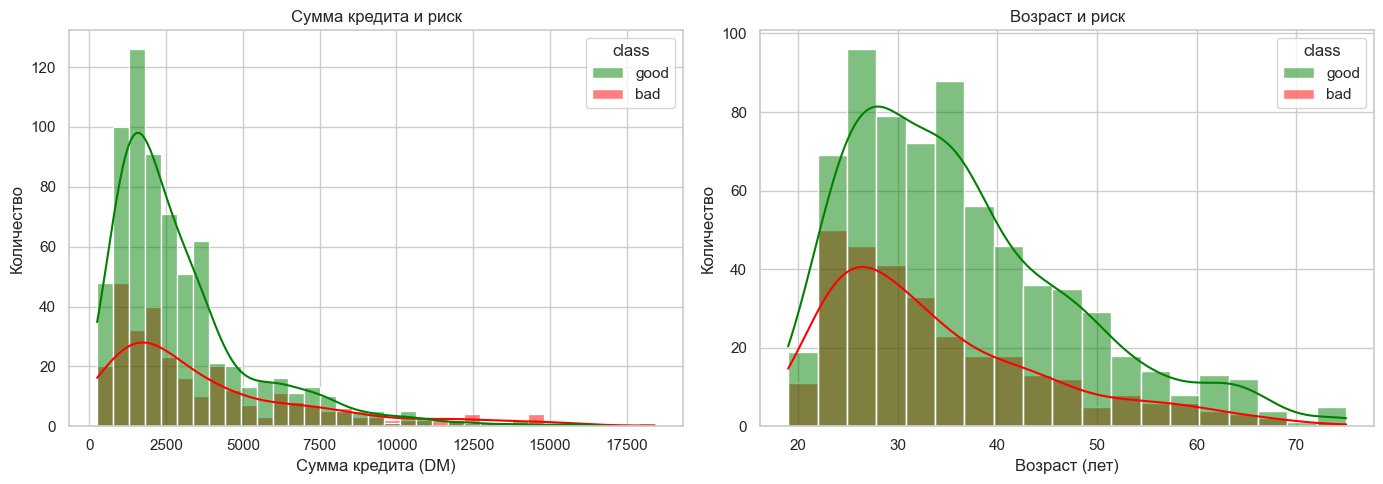

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='credit_amount', hue='class', kde=True, ax=axes[0], palette={'good':'green', 'bad':'red'})
axes[0].set_title('Сумма кредита и риск')
axes[0].set_xlabel('Сумма кредита (DM)')
axes[0].set_ylabel('Количество')

sns.histplot(data=df, x='age', hue='class', kde=True, ax=axes[1], palette={'good':'green', 'bad':'red'})
axes[1].set_title('Возраст и риск')
axes[1].set_xlabel('Возраст (лет)')
axes[1].set_ylabel('Количество')
plt.tight_layout()

In [21]:
df['class'] = df['class'].map({'good':1, 'bad':0})

df_encoded = pd.get_dummies(df, drop_first=True)

print(f"Количество колонок ДО:{df.shape[1]}")
print(f"Количество колонок ПОСЛЕ:{df_encoded.shape[1]}")

pd.set_option('display.max_columns', None)
display(df_encoded.head())

Количество колонок ДО:21
Количество колонок ПОСЛЕ:49


,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,class,checking_status_<0,checking_status_>=200,checking_status_no checking,credit_history_critical/other existing credit,credit_history_delayed previously,credit_history_existing paid,credit_history_no credits/all paid,purpose_domestic appliance,purpose_education,purpose_furniture/equipment,purpose_new car,purpose_other,purpose_radio/tv,purpose_repairs,purpose_retraining,purpose_used car,savings_status_500<=X<1000,savings_status_<100,savings_status_>=1000,savings_status_no known savings,employment_4<=X<7,employment_<1,employment_>=7,employment_unemployed,personal_status_male div/sep,personal_status_male mar/wid,personal_status_male single,other_parties_guarantor,other_parties_none,property_magnitude_life insurance,property_magnitude_no known property,property_magnitude_real estate,other_payment_plans_none,other_payment_plans_stores,housing_own,housing_rent,job_skilled,job_unemp/unskilled non res,job_unskilled resident,own_telephone_yes,foreign_worker_yes
0,6,1169,4,4,67,2,1,1,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,True,False,False,True,True,False,True,False,True,False,False,True,True
1,48,5951,2,2,22,1,1,0,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,False,True,False,True,False,False,False,True
2,12,2096,2,3,49,1,2,1,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,True,False,False,True,True,False,True,False,False,False,True,False,True
3,42,7882,2,4,45,1,2,1,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,True,False,True,False,False,True,False,False,False,True,False,False,False,True
4,24,4870,3,4,53,2,2,0,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,True,False,True,False,False,False,True,False,False,False,True


In [22]:
df_encoded.to_csv('../data/processed/german_credit_encoded.csv', index=False)